In [1]:
# Import all the Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , LSTM

In [2]:
# upLoad the Dataset
from google.colab import files
uploaded = files.upload()

Saving bitcoin_ohlcv.csv to bitcoin_ohlcv.csv


In [3]:
# Load the Dataset
df = pd.read_csv('bitcoin_ohlcv.csv',skiprows=2)
df.head()

,Date,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [4]:
# Fix the Columns Name
df.columns = ['Date','Price','Close','High','Low','Volume']

In [5]:
# Checking if the columns are changed or not
df.head()

,Date,Price,Close,High,Low,Volume
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [6]:
# Taking only 'Close' Column as LSTM Works only on one column
data = df[['Close']]

In [7]:
#Scale the Data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [8]:
# Create Sequences (Uses last 60 data to predict next day)
X=[]
Y=[]

for i in range(60, len(scaled_data)):
  X.append(scaled_data[i-60:i])
  Y.append(scaled_data[i])


In [9]:
# Convert to Numpy
X=np.array(X)
Y=np.array(Y)


In [10]:
# Check the Shape
print(X.shape)
print(Y.shape)

(1766, 60, 1)
(1766, 1)


In [11]:
# LSTM Model Code
# DownLoad the Required Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM , Dense


In [12]:
# Create A Model
model = Sequential()

#First LSTM Layer(learns basic patterns)
model.add(LSTM(units=50,return_sequences=True,input_shape=(X.shape[1],1)))

# Second LSTM Layer(learns deeper patterns)
model.add(LSTM(units=50))

# Output Layer
model.add(Dense(1))

# Compile the Model
model.compile(optimizer="adam",loss="mean_squared_error")

# Train the Model
model.fit(X,Y, epochs=5 , batch_size=32)



Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0162
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.0010
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 9.3790e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 8.6489e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 8.2275e-04


In [13]:
# Predict the values
predictions = model.predict(X)

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [19]:
# Inverse Transform
predictions = model.predict(X)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y)

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [18]:
# Recreate X and y

X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

import numpy as np

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1766, 60, 1)
y shape: (1766, 1)


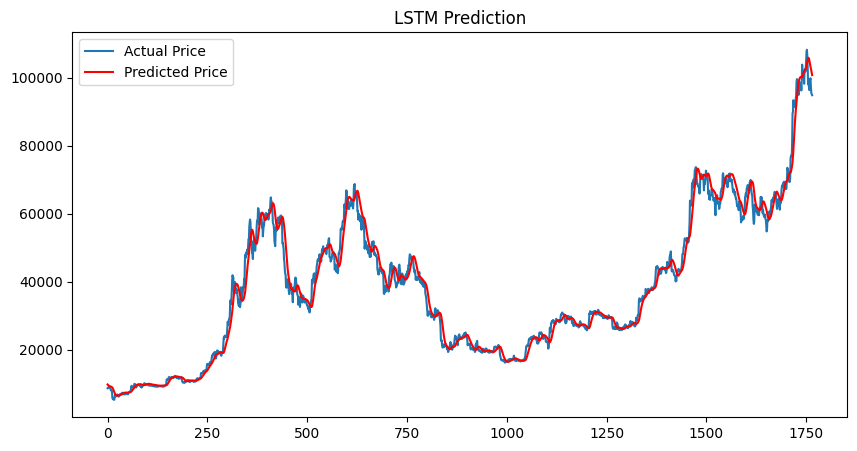

In [20]:
# Plot the graph
plt.figure(figsize=(10,5))

plt.plot(actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price', color='red')

plt.legend()
plt.title("LSTM Prediction")

plt.show()

In [22]:
plt.savefig("lstm_output.png")

<Figure size 640x480 with 0 Axes>